In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from matplotlib.ticker import NullLocator
from matplotlib.ticker import ScalarFormatter

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 10,
        "lines.linewidth": 1.5,
        "lines.markersize": 4,
        "font.family": "sans-serif",
        "text.usetex": False,
    }
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
def load_run_data(run_id, base_dir="data_dir"):
    folder_path = os.path.join(base_dir, str(run_id))
    metrics_path = os.path.join(folder_path, "csv", "version_0", "metrics.csv")
    hparams_path = os.path.join(folder_path, "csv", "version_0", "hparams.yaml")

    if not os.path.exists(metrics_path) or not os.path.exists(hparams_path):
        print(f"Skipping run {run_id}: Missing files.")
        return None

    with open(hparams_path, "r") as f:
        try:
            hparams = yaml.safe_load(f)
        except yaml.YAMLError as e:
            print(f"Error reading yaml for run {run_id}: {e}")
            return None

    try:
        data_config = hparams.get("data", {})
        model_config = hparams.get("model", {})
        net_config = model_config.get("net_config", {})
        scheduler_config = model_config.get("scheduler", {})

        train_subset = data_config.get("train_subset")
        arch = net_config.get("arch")
        dropout_rate = net_config.get("dropout_rate")

        scheduler_target = scheduler_config.get("_target_", "Unknown")
        scheduler_name = scheduler_target.split(".")[-1]
        seed = hparams.get("seed")

    except AttributeError:
        print(f"Skipping run {run_id}: Malformed hparams.")
        return None

    try:
        df_metrics = pd.read_csv(metrics_path)
    except Exception as e:
        print(f"Error reading metrics for run {run_id}: {e}")
        return None

    metrics_of_interest = ["val/acc", "val/au", "val/eu", "val/loss", "val/tu"]

    run_data = {
        "run_id": run_id,
        "train_subset": train_subset,
        "arch": arch,
        "dropout_rate": dropout_rate,
        "seed": seed,
        "scheduler": scheduler_name,
    }

    for metric in metrics_of_interest:
        if metric in df_metrics.columns:
            valid_values = df_metrics[metric].dropna()
            if not valid_values.empty:
                run_data[metric] = valid_values.iloc[-1]
            else:
                run_data[metric] = None
        else:
            run_data[metric] = None

    return run_data

In [4]:
data_dirs = [
    "../logs/train/multiruns/2026-01-14_05-45-18",
]
all_runs = []

for data_dir in data_dirs:
    data_dir = Path(data_dir)

    # infer max run id from folders (safer than range(141))
    run_ids = sorted(int(p.name) for p in data_dir.iterdir() if p.is_dir() and p.name.isdigit())

    for run_id in run_ids:
        run_data = load_run_data(run_id, data_dir)
        if run_data:
            all_runs.append(run_data)

df = pd.DataFrame(all_runs)
df["train_subset"] = pd.to_numeric(df["train_subset"])
df

,run_id,train_subset,arch,dropout_rate,seed,scheduler,val/acc,val/au,val/eu,val/loss,val/tu
0,0,12500,vit_small,0.5,1234,CosineAnnealingLR,0.5488,0.187279,0.810623,2.974097,0.997902
1,1,25000,vit_small,0.5,1234,CosineAnnealingLR,0.6111,0.146649,0.816285,2.752127,0.962934
2,2,37500,vit_small,0.5,1234,CosineAnnealingLR,0.6470,0.129247,0.806589,2.662134,0.935836
3,3,50000,vit_small,0.5,1234,CosineAnnealingLR,0.6727,0.118366,0.786850,2.513174,0.905216


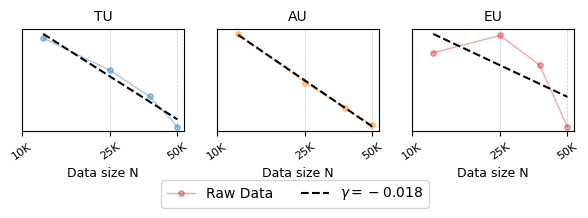

In [15]:
# 1. Configuration
metrics = ["val/tu", "val/au", "val/eu"]
titles = {"val/tu": "TU", "val/au": "AU", "val/eu": "EU"}
colors = {"val/tu": "tab:blue", "val/au": "tab:orange", "val/eu": "tab:red"}
labels_map = {"val/tu": "TU", "val/au": "AU", "val/eu": "EU"}

# Create 1x3 subplots
fig, axes = plt.subplots(1, 3, figsize=(6, 2), sharey=False, sharex=True)

# 2. Filtering for ViT Small
arch = "vit_small"
dropout_rate = 0.5
subset_df = df[(df["arch"] == arch) & (df["dropout_rate"] == dropout_rate)]

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    # Plot individual seeds
    for fold in subset_df["seed"].unique():
        fold_data = subset_df[subset_df["seed"] == fold].sort_values("train_subset")
        
        ax.plot(
            fold_data["train_subset"],
            fold_data[metric],
            color=colors[metric],
            marker='o',
            linewidth=1,
            alpha=0.4,
            label="Raw Data" if fold == subset_df["seed"].unique()[0] else ""
        )

        # 3. Power-law fit (log-log linear regression)
        x_vals = fold_data["train_subset"].values
        y_vals = fold_data[metric].values
        
        log_x = np.log(x_vals)
        log_y = np.log(y_vals)
        slope, intercept = np.polyfit(log_x, log_y, 1)
        
        x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
        y_line = np.exp(slope * np.log(x_line) + intercept)
        
        # Plot the fit line
        ax.plot(x_line, y_line, color="black", linewidth=1.5, linestyle="--", 
                label=rf"$\gamma = {slope:.3f}$")

    # 4. Subplot Aesthetics
    ax.set_title(titles[metric])
    ax.set_xlabel("Data size N")
    ax.set_ylabel("")
    
    ax.set_xscale("log")
    ax.set_yscale("log")
    
    # Formatting ticks to be readable
    ax.xaxis.set_major_locator(NullLocator())
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xticks((10000, 25000, 50000), ("10K", "25K", "50K"), rotation=35)
    ax.yaxis.set_major_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())
    #ax.set_yticks((0.1, 1), ("0.1", "1"))
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

handles, labels = axes[-1].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(), by_label.keys(), loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.1)
)
plt.tight_layout()
plt.show()

In [17]:
df.to_csv('figure4_unc(left).csv', index=False) 